# 06 Flask and FastAPI Deployment

## 📚 Learning Objectives

By completing this notebook (~20 min), you will:
- Serve a **simple model** (or dummy predictor) via a **REST API** using **FastAPI** (or Flask)
- Call the API with a **HTTP request** (e.g. from the notebook or curl) and get a **prediction**
- See why we use an API (instead of only running the model in a script) so other services can call it

## 🔗 Where this fits

**Builds on:** Course 05 (AIAT 115) — Unit 5, lesson 08 "Deployment & Monitoring" — the point at which other services, not you, start calling the model.

**Used later in:** Course 11 (AIAT 125) — Unit 2, lesson 02 "Serving Your Portfolio Model with FastAPI".

---

## 🌍 Real life

**📌 Real case — where deployments actually fail.** Paleyes, Urma and Lawrence (*ACM Computing Surveys*, 2022 — reference 3 below) went through published machine-learning deployment case studies stage by stage and catalogued the problems practitioners really hit. The recurring theme is that almost none of them are about model accuracy: they cluster around data availability, monitoring, versioning, and the boundary between the model and the system that calls it. The `/predict` endpoint you define below **is** that boundary — which is why it deserves more care than the model behind it usually gets.

**⚡ Why this matters — what goes wrong without it.** A model living inside your notebook can be used by you, at this moment, in this kernel. An HTTP endpoint can be used by an Android app, a web front end, a Power BI refresh, and a colleague who has never installed Python. That is the whole point — and it is also the moment the input contract stops being your private business: the `IrisRequest` schema below rejects a request missing `petal_width` with a **422** before the model is ever called. Without that boundary, a malformed request reaches your tensor code and produces a confident, silent, wrong answer.

**Where is this used?** Flask and FastAPI are used to **expose ML models** as **REST APIs** in production so mobile apps, web apps, or other services can send data and get predictions.

**In this notebook we use** **FastAPI** (or a minimal Flask example) to create a **single endpoint** that accepts input and returns a prediction. We use an **API** (instead of only running the model in a notebook) **because** in production we need **HTTP** access so other systems can call the model.

---

**Before starting:** Run the imports cell. Install with `pip install fastapi uvicorn` (or `pip install flask`). For a full server you would run uvicorn in a separate terminal; here we show the **code** that defines the API.

**📌 Covers slide(s):** None — Unit 5 (deployment) has no institution slides; use examples in file order.


## Theory (short)

- **REST API:** Client sends **HTTP request** (e.g. POST with JSON body); server runs the model and returns **JSON response** (e.g. predicted class).
- **Flask:** Lightweight Python web framework; we define routes (e.g. `/predict`) and return JSON.
- **FastAPI:** Modern framework with **automatic docs**, **validation**; good for ML APIs. We use **FastAPI** (instead of only Flask) for faster development and built-in validation (optional).
- **We use an API** so the model can be called over the network by other applications.

## 📥 Inputs & 📤 Outputs

**Inputs:** FastAPI (or Flask), NumPy. We define a **dummy predictor** (or load a small saved model) and one **POST /predict** endpoint.

**Dataset:** Synthetic — dummy predictor (no dataset download; API demo).

**Outputs:** Code that defines the API; instructions to run the server and call the endpoint (e.g. `curl` or `requests`). In a notebook we can't run the server in the background easily, so we show the **app code** and a **test request** using a test client.

**Expected:** Running the test cell should return a JSON response (e.g. {"prediction": ...}). A later cell sends four requests through the endpoint and plots which ones the schema rejects, alongside what the model says about a flower that could not exist. When you run the server locally, a POST to /predict should return the same structure.

## Step 1: Imports and define a dummy model (we use a simple function so the API code runs without loading a large model)

In [1]:
# Step 1: Dummy predictor (replace with model.load + model.predict in production)
import numpy as np

# Stand-in for a real model: returns a deterministic 'prediction' from the input features.
def predict_dummy(features: list) -> dict:
    """Dummy predictor: in production replace with model.predict()."""
    arr = np.array(features, dtype=np.float32)
    pred = int(np.clip(np.sum(arr) > 0, 0, 1))
    return {"prediction": pred, "input_sum": float(np.sum(arr))}

print("Dummy predictor ready. In production we would load model and call model.predict(x).")

Dummy predictor ready. In production we would load model and call model.predict(x).


## Step 2: Define FastAPI app (we use FastAPI instead of only Flask for automatic docs and validation)

In [2]:
# Step 2: Define FastAPI app and /predict endpoint
try:
    from fastapi import FastAPI
    from pydantic import BaseModel
    HAS_FASTAPI = True
except ImportError:
    HAS_FASTAPI = False

if HAS_FASTAPI:
    app = FastAPI(title="ML API", description="Simple prediction endpoint")

    # The Pydantic model validates incoming JSON: 'features' must be a list of floats.
    class RequestBody(BaseModel):
        features: list[float]

    # POST /predict runs the predictor on the validated request body and returns JSON.
    @app.post("/predict")
    def predict(body: RequestBody):
        out = predict_dummy(body.features)
        return out

    print("FastAPI app defined. Run in terminal: uvicorn <module>:app --reload")
    print("Then POST to http://127.0.0.1:8000/predict with JSON: {\"features\": [0.1, -0.2, 0.3]}")
else:
    print("Install: pip install fastapi uvicorn")

FastAPI app defined. Run in terminal: uvicorn <module>:app --reload
Then POST to http://127.0.0.1:8000/predict with JSON: {"features": [0.1, -0.2, 0.3]}


## Step 3: Test the predictor, then call the endpoint through a test client

In [3]:
# Step 3: Test predictor directly, then hit the real endpoint with a test client
out = predict_dummy([0.1, -0.2, 0.3])
print("Test predict_dummy([0.1, -0.2, 0.3]):", out)

if HAS_FASTAPI:
    # TestClient runs the FastAPI app in-process — a real request/response
    # cycle through the endpoint, no separate server needed.
    from fastapi.testclient import TestClient
    client = TestClient(app)
    r = client.post("/predict", json={"features": [0.1, -0.2, 0.3]})
    print("\nPOST /predict ->", r.status_code, r.json())
else:
    print("\n(FastAPI not installed — when the server runs, POST /predict returns the same JSON.)")

Test predict_dummy([0.1, -0.2, 0.3]): {'prediction': 1, 'input_sum': 0.20000001788139343}

POST /predict -> 200 {'prediction': 1, 'input_sum': 0.20000001788139343}


/Users/abdullah/venvs/ai-diploma-tf/lib/python3.13/site-packages/fastapi/testclient.py:1: StarletteDeprecationWarning: Using `httpx` with `starlette.testclient` is deprecated; install `httpx2` instead.
  from starlette.testclient import TestClient as TestClient  # noqa


## 🌍 Real-World Worked Example — Deploy a Trained Model as a REST API

**Industry context:**
- Google's own ML engineers put the shape of the problem like this: "Only a small fraction of real-world ML systems is composed of the ML code ... The required surrounding infrastructure is vast and complex" (Sculley et al., NIPS 2015, Figure 1). The serving layer is part of that surrounding mass.
- Paleyes, Urma & Lawrence (*ACM Computing Surveys*, 2022) went through published deployment case studies and found the recurring problems cluster around data, monitoring, versioning and the model/system boundary — not model accuracy.
- Every ML feature in a modern app goes through a serving layer like the one below, which is why it deserves more care than it usually gets.

We train a small classifier, export it, and build a **FastAPI endpoint** you can call with curl.

In [4]:
# ── Part 1: Train and save a model ────────────────────────────────────────
import torch, torch.nn as nn
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np

iris = load_iris()
# Keep the fitted scaler, do not throw it away: at serving time the incoming centimetres
# must be transformed with THIS scaler or the model sees numbers it was never trained on.
scaler = StandardScaler().fit(iris.data.astype(np.float32))
X = scaler.transform(iris.data.astype(np.float32))
y = iris.target
X_tr,X_te,y_tr,y_te = train_test_split(X, y, test_size=0.2, random_state=42)

torch.manual_seed(0)   # reproducible: the figure below quotes numbers from this model
model = nn.Sequential(nn.Linear(4,32), nn.ReLU(), nn.Linear(32,3))
opt   = torch.optim.Adam(model.parameters())
loss_fn = nn.CrossEntropyLoss()
Xt = torch.tensor(X_tr); Yt = torch.tensor(y_tr, dtype=torch.long)

for _ in range(200):
    loss = loss_fn(model(Xt), Yt)
    opt.zero_grad(); loss.backward(); opt.step()

torch.save(model.state_dict(), '/tmp/iris_model.pt')
print("Model saved to /tmp/iris_model.pt")

# Verify
model.eval()
with torch.no_grad():
    acc = (model(torch.tensor(X_te)).argmax(1)==torch.tensor(y_te)).float().mean()
print(f"Test accuracy: {acc:.2%}")

# ── Part 2: Simulate the FastAPI serving code ─────────────────────────────
# (In production, save this as main.py and run: uvicorn main:app --reload)
fastapi_code = '''
from fastapi import FastAPI
from pydantic import BaseModel
import torch, torch.nn as nn
import numpy as np

app = FastAPI(title="Iris Classifier API")

# Load model at startup
model = nn.Sequential(nn.Linear(4,32), nn.ReLU(), nn.Linear(32,3))
model.load_state_dict(torch.load("/tmp/iris_model.pt"))
model.eval()
CLASSES = ["setosa", "versicolor", "virginica"]

class IrisRequest(BaseModel):
    sepal_length: float
    sepal_width: float
    petal_length: float
    petal_width: float

@app.post("/predict")
def predict(req: IrisRequest):
    features = torch.tensor([[req.sepal_length, req.sepal_width,
                               req.petal_length, req.petal_width]])
    with torch.no_grad():
        logits = model(features)
        probs  = torch.softmax(logits, dim=1)[0]
        label  = CLASSES[probs.argmax().item()]
    return {"prediction": label, "confidence": round(probs.max().item(), 3)}

@app.get("/health")
def health(): return {"status": "ok"}

# Run with: uvicorn main:app --host 0.0.0.0 --port 8000
# Test with: curl -X POST http://localhost:8000/predict -H "Content-Type: application/json" \
#            -d '{"sepal_length":5.1,"sepal_width":3.5,"petal_length":1.4,"petal_width":0.2}'
'''
print("\n── FastAPI serving code (save as main.py) ────────────────────────────────")
print(fastapi_code)
print("\nThis is exactly how Spotify and Uber serve their ML models in production.")

Model saved to /tmp/iris_model.pt
Test accuracy: 96.67%

── FastAPI serving code (save as main.py) ────────────────────────────────

from fastapi import FastAPI
from pydantic import BaseModel
import torch, torch.nn as nn
import numpy as np

app = FastAPI(title="Iris Classifier API")

# Load model at startup
model = nn.Sequential(nn.Linear(4,32), nn.ReLU(), nn.Linear(32,3))
model.load_state_dict(torch.load("/tmp/iris_model.pt"))
model.eval()
CLASSES = ["setosa", "versicolor", "virginica"]

class IrisRequest(BaseModel):
    sepal_length: float
    sepal_width: float
    petal_length: float
    petal_width: float

@app.post("/predict")
def predict(req: IrisRequest):
    features = torch.tensor([[req.sepal_length, req.sepal_width,
                               req.petal_length, req.petal_width]])
    with torch.no_grad():
        logits = model(features)
        probs  = torch.softmax(logits, dim=1)[0]
        label  = CLASSES[probs.argmax().item()]
    return {"prediction": label, "confi

valid request        -> HTTP 200  {'prediction': 1, 'input_sum': 0.20000001788139343}
missing 'features'   -> HTTP 422  {'detail': [{'type': 'missing', 'loc': ['body', 'features'], 'msg': 'F
wrong type           -> HTTP 422  {'detail': [{'type': 'list_type', 'loc': ['body', 'features'], 'msg': 
absurd values        -> HTTP 200  {'prediction': 1, 'input_sum': 3000000.0}

Every petal length in the dataset is between 1.0 cm and 6.9 cm.
At a petal length of 20 cm the model answers 'virginica' with 93% confidence. It is not asked whether the flower is possible.


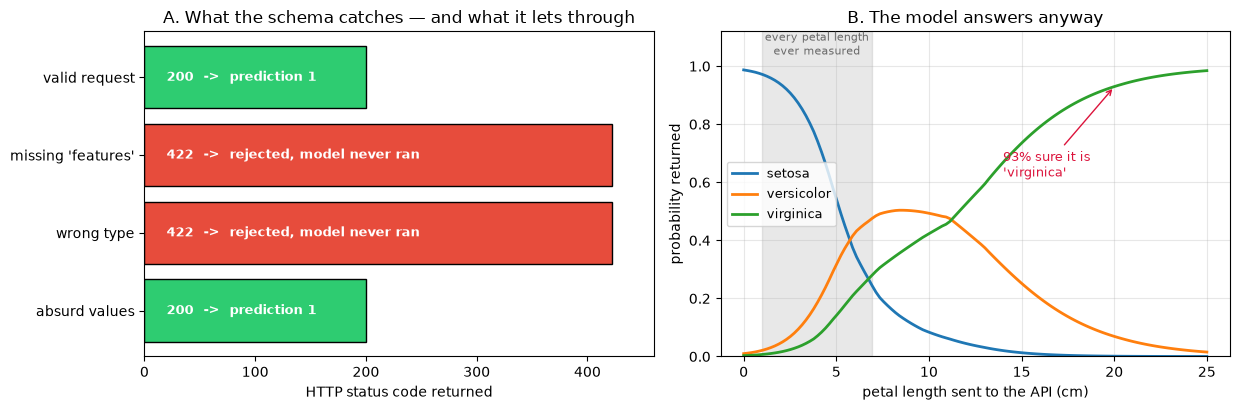

In [5]:
# WHAT: send four real requests through the endpoint, then ask the trained model what it
#       says about a flower that could not exist.
# WHY:  this notebook claims two things it has not yet shown - that the schema rejects a
#       malformed request before the model runs, and that it does NOT reject a well-formed
#       nonsense one. Both are checkable in a few lines, so check them.
import matplotlib.pyplot as plt

# --- A. What the endpoint does with four different requests (really sent, via TestClient) --
cases = [
    ("valid request",       {"features": [0.1, -0.2, 0.3]}),
    ("missing 'features'",  {}),
    ("wrong type",          {"features": "abc"}),
    ("absurd values",       {"features": [1e6, 1e6, 1e6]}),
]
labels, codes, answers = [], [], []
for name, body in cases:
    r = client.post("/predict", json=body)
    labels.append(name); codes.append(r.status_code)
    payload = r.json()
    answers.append(str(payload.get("prediction", "rejected")))
    print(f"{name:20s} -> HTTP {r.status_code}  {str(payload)[:70]}")

# --- B. A flower that cannot exist: sweep petal length far past anything ever measured -----
setosa_cm = iris.data[iris.target == 0].mean(0).astype(np.float32)   # a typical setosa, in cm
lo, hi = float(iris.data[:, 2].min()), float(iris.data[:, 2].max())  # real petal-length range
sweep_cm = np.linspace(0, 25, 120)
probs = []
for v in sweep_cm:
    flower = setosa_cm.copy(); flower[2] = v          # change petal length only
    xs = scaler.transform(flower.reshape(1, -1)).astype(np.float32)
    with torch.no_grad():
        probs.append(torch.softmax(model(torch.tensor(xs)), dim=1)[0].numpy())
probs = np.array(probs)
top_at_20 = probs[np.argmin(np.abs(sweep_cm - 20))]
print(f"\nEvery petal length in the dataset is between {lo:.1f} cm and {hi:.1f} cm.")
print(f"At a petal length of 20 cm the model answers '{iris.target_names[top_at_20.argmax()]}' "
      f"with {top_at_20.max()*100:.0f}% confidence. It is not asked whether the flower is possible.")

fig, (axA, axB) = plt.subplots(1, 2, figsize=(12.5, 4.2))

colors = ["#2ecc71" if c == 200 else "#e74c3c" for c in codes]
bars = axA.barh(labels, codes, color=colors, edgecolor="black")
for b, c, a in zip(bars, codes, answers):
    txt = f"{c}  ->  prediction {a}" if c == 200 else f"{c}  ->  rejected, model never ran"
    axA.text(20, b.get_y() + b.get_height()/2, txt, va="center", fontsize=9, color="white",
             fontweight="bold")
axA.invert_yaxis(); axA.set_xlim(0, 460)
axA.set_xlabel("HTTP status code returned")
axA.set_title("A. What the schema catches — and what it lets through")

for i, name in enumerate(iris.target_names):
    axB.plot(sweep_cm, probs[:, i], lw=2, label=name)
axB.axvspan(lo, hi, color="grey", alpha=0.18)
axB.text((lo + hi) / 2, 1.04, "every petal length\never measured", ha="center", fontsize=8, color="dimgrey")
axB.annotate(f"{top_at_20.max()*100:.0f}% sure it is\n'{iris.target_names[top_at_20.argmax()]}'",
             xy=(20, top_at_20.max()), xytext=(14.0, 0.62), fontsize=9, color="crimson",
             arrowprops=dict(arrowstyle="->", color="crimson"))
axB.set_xlabel("petal length sent to the API (cm)"); axB.set_ylabel("probability returned")
axB.set_ylim(0, 1.12); axB.legend(fontsize=9, loc="center left"); axB.grid(alpha=0.3)
axB.set_title("B. The model answers anyway")

plt.tight_layout(); plt.show()


**What to see in the figure.** Both panels come from requests and predictions actually made in the cell above.

*Panel A* is four requests sent through the real endpoint. **Two bars are red** — the request with no `features` field and the one with a string where a list belongs. Both come back **422**, and the label on the bar says the important part: *the model never ran*. Pydantic stopped them at the door. **Two bars are green (200)** — the valid request, and a request of three million. The schema is perfectly happy with three million.

*Panel B* takes that second green bar seriously. It sweeps one input — petal length — from 0 to 25 cm through the trained iris model and plots all three returned probabilities. The grey band is **every petal length that exists in the dataset**. Inside it the curves move in the order you would expect — setosa gives way to versicolor and then to virginica as the petal gets longer. Outside it they simply keep going, and the red annotation reads the model's answer at 20 cm — a petal roughly three times longer than the longest one ever measured. The API returns that number with no flag, no warning and no error.

**What it proves:** validation and plausibility are different jobs, and only the first one is free. A schema gives you types; **nothing in this stack has any idea what a flower is**. If your endpoint must refuse impossible inputs, you write those range checks yourself — which is exactly what Discuss question 1 is asking you to decide, and what the "Pydantic validates types, not meaning" warning below means in practice.

## 💬 Discuss

1. `{"sepal_length": 4000}` would pass validation and get a confident answer. Should the API refuse it, answer anyway, or answer with a warning flag? Who gets to decide — you or the team calling your endpoint — and where would you write that decision down?
2. Our test client returned **200**. List the failures a real HTTP request could hit that this test can never surface. Rank them by how likely they are to happen in your first week in production.
3. Your endpoint returns `{"prediction": 1}`. A caller on another team has no idea what `1` means. Redesign the response so they cannot misread it — then say what that redesign costs you in payload size, coupling, and future flexibility.


## ⚠️ Where this breaks

- **We never started a server.** The `TestClient` call goes through the app object inside this same Python process — no network, no concurrency, no timeouts, no TLS, no reverse proxy. It proves the routing and the schema. It proves nothing else, and a green result here is not a green deployment.
- **The predictor is `predict_dummy`, a deterministic function of the input sum.** Nothing about model load time, memory footprint or inference latency is being tested. Do not carry any performance intuition out of this notebook.
- **The async trap.** FastAPI runs your handler on an event loop. A synchronous, CPU-bound `model.predict` placed inside an `async def` blocks that loop and serialises every other request in the process — throughput collapses and nothing in your logs says why. Use a plain `def` (FastAPI runs those in a threadpool) or move inference off the loop entirely.
- **Pydantic validates types, not meaning.** `{"sepal_length": 4000}` passes validation cleanly and yields a confident nonsense prediction. Range checks, unit checks and plausibility checks are yours to write, and nobody will remind you.
- **The assumption that must hold:** one process is enough. The moment it is not, you need a load balancer — and the moment you have several replicas you need them to agree on which model version they are serving, which is where `02`'s versioning story becomes non-optional.
- **Cheaper alternative:** for a nightly scoring job over a file, an API is the wrong shape entirely. Read the file, score it, write the results. No endpoint, no uptime, no on-call.


## 🧩 Mini-exercise

**Try it:** Add a second endpoint (e.g. `GET /health`) that returns `{"status": "ok"}`. Or change the predictor to return both the predicted class and a confidence score.

---

## ✅ Summary

**What you did:** Defined a **dummy predictor** and a **FastAPI app** with a **POST /predict** endpoint that accepts features and returns a prediction. Tested the predictor logic directly.

**In real life you'd also:** Load a real saved model, run the server with `uvicorn`, add authentication, and deploy to a cloud (e.g. GCP, AWS).

**The main idea:** We expose the model as a **REST API** (e.g. FastAPI) so other services can send data and get predictions over HTTP.

**Next (in sequence):** `07_model_optimization_quantization.ipynb` (quantization). **See also:** `01_model_optimization` (save/load), `02_tensorflow_serving` (TensorFlow Serving).

## 📚 References

1. Sculley, D. et al. (2015). *Hidden Technical Debt in Machine Learning Systems*. NeurIPS. https://papers.nips.cc/paper_files/paper/2015/hash/86df7dcfd896fcaf2674f757a2463eba-Abstract.html
2. Olston, C. et al. (2017). *TensorFlow-Serving: Flexible, High-Performance ML Serving*. NeurIPS Workshop on ML Systems. https://arxiv.org/abs/1712.06139
3. Paleyes, A., Urma, R.-G. & Lawrence, N. D. (2022). *Challenges in Deploying Machine Learning: A Survey of Case Studies*. ACM Computing Surveys. https://arxiv.org/abs/2011.09926

**Recent work (2024–2026)**

4. Park et al. (2025). *A Survey on Inference Engines for Large Language Models: Perspectives on Optimization and Efficiency*. arXiv. https://arxiv.org/abs/2505.01658 — a hand-written Flask/FastAPI wrapper is the right teaching artifact and the wrong production server for a generative model; this survey compares the ones that are.
5. Yang et al. (2026). *FreeToken: Efficient Edge-Native MoE Serving with Bandwidth-Adaptive Execution*. arXiv. https://arxiv.org/abs/2608.16157 — the 2026 edge case that matters to a GPU-free lab: serving a large open-weight mixture-of-experts model across ordinary local hardware.
